# Anhedonic AI — MMLU Difficulty-Bound Eval
**Model A:** Qwen2-VL-7B | Layers 18–27 ablated | ~1,363 neurons | 0.257% of network

| | Design | N subjects | Purpose |
|---|---|---|---|
| **This eval** | Choose 1 of 4 questions, reward ∝ difficulty (hardest→40pts) | 10 | Cross-domain anhedonic replication on MMLU |

**Statistics:** Paired t-tests (one-tailed H₁: Model A < Baseline), 95% CI, K=5 fold error bars.

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
from scipy import stats as sp_stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.2, 'grid.linewidth': 0.5,
})
BL = '#2563EB'   # baseline blue
MA = '#DC2626'   # model A red
GR = '#16A34A'   # green — anhedonic direction
CH = '#9CA3AF'   # chance gray

CHANCE_MEAN = 25.0
CHANCE_RS   = 0.25
RESULTS_DIR = 'results'
FIG_DIR     = 'results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# ── Helpers (identical to reference notebook) ──────────────────────────────
def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def add_bracket(ax, x1, x2, y, p, h=0.5, fs=12):
    stars = sig_stars(p)
    col   = 'black' if stars != 'ns' else CH
    ax.plot([x1,x1,x2,x2], [y,y+h,y+h,y], lw=1.2, color=col)
    ax.text((x1+x2)/2, y+h+0.05, stars, ha='center', va='bottom', fontsize=fs, color=col)

def paired_ttest(b_vals, a_vals):
    delta  = a_vals - b_vals
    t1, p1 = sp_stats.ttest_rel(a_vals, b_vals, alternative='less')
    t2, p2 = sp_stats.ttest_rel(a_vals, b_vals, alternative='two-sided')
    ci     = sp_stats.t.interval(0.95, len(delta)-1,
                                  loc=delta.mean(), scale=sp_stats.sem(delta))
    return dict(delta=delta.mean(), t1=t1, p1=p1, t2=t2, p2=p2, ci=ci, n=len(delta))

def get_95ci(arr):
    return 1.96 * np.std(arr) / np.sqrt(len(arr))

# ── Load JSON ──────────────────────────────────────────────────────────────
with open(f'{RESULTS_DIR}/eval_model_a_mmlu_difficulty.json') as f:
    data = json.load(f)

subjects = data['subjects_evaluated']

# Build per-subject DataFrames matching the reference notebook's e1b / e1a structure
# Each row = one subject; columns = mean_pts_mean, mean_pts_std, rate_40pt_mean, rate_40pt_std
rows_b, rows_a = [], []
for subj in subjects:
    d = data['per_subject'][subj]
    b_pts  = np.array([r[0] for r in d['baseline']])
    b_opt  = np.array([r[1] for r in d['baseline']])
    a_pts  = np.array([r[0] for r in d['model_a']])
    a_opt  = np.array([r[1] for r in d['model_a']])
    rows_b.append({'subject': subj,
                   'mean_pts_mean': b_pts.mean(), 'mean_pts_std': b_pts.std(),
                   'rate_40pt_mean': b_opt.mean(),'rate_40pt_std': b_opt.std()})
    rows_a.append({'subject': subj,
                   'mean_pts_mean': a_pts.mean(), 'mean_pts_std': a_pts.std(),
                   'rate_40pt_mean': a_opt.mean(),'rate_40pt_std': a_opt.std()})

e1b = pd.DataFrame(rows_b).set_index('subject')
e1a = pd.DataFrame(rows_a).set_index('subject')

print(f'Loaded {len(subjects)} subjects, 5 folds each')
print(f'Subjects: {subjects}')

Loaded 10 subjects, 5 folds each
Subjects: ['medical_genetics', 'college_computer_science', 'anatomy', 'professional_accounting', 'global_facts', 'elementary_mathematics', 'electrical_engineering', 'college_mathematics', 'sociology', 'college_chemistry']


In [2]:
# ── Paired t-tests (same as reference notebook) ────────────────────────────
b_pts_arr = e1b['mean_pts_mean'].values
a_pts_arr = e1a['mean_pts_mean'].values
b_40_arr  = e1b['rate_40pt_mean'].values
a_40_arr  = e1a['rate_40pt_mean'].values

tt_pts = paired_ttest(b_pts_arr, a_pts_arr)
tt_40  = paired_ttest(b_40_arr,  a_40_arr)

print('=' * 68)
print('PAIRED T-TEST RESULTS  (one-tailed H₁: Model A < Baseline)')
print('=' * 68)
for label, tt, scale, unit in [
    ('Mean pts chosen',    tt_pts, 1,   'pts'),
    ('40pt choice rate',   tt_40,  100, 'pp'),
]:
    print(f'\n{label}:')
    print(f'  N={tt["n"]}  Δ={tt["delta"]*scale:+.3f}{unit}  '
          f'95%CI=[{tt["ci"][0]*scale:.3f},{tt["ci"][1]*scale:.3f}]{unit}')
    print(f'  One-tailed: t={tt["t1"]:+.3f}  p={tt["p1"]:.4f}  {sig_stars(tt["p1"])}')
    print(f'  Two-tailed: t={tt["t2"]:+.3f}  p={tt["p2"]:.4f}  {sig_stars(tt["p2"])}')
print(f'\n{"─"*68}')
print(f'  {"Metric":<30} {"Δ":>10}  {"1-tail p":>10}  {"2-tail p":>10}  Sig')
print(f'  {"─"*62}')
for lbl, tt, scale, unit in [
    ('Mean pts',        tt_pts, 1,   'pts'),
    ('40pt rate',       tt_40,  100, 'pp'),
]:
    print(f'  {lbl:<30} {tt["delta"]*scale:>+9.3f}{unit}  '
          f'{tt["p1"]:>10.4f}  {tt["p2"]:>10.4f}  {sig_stars(tt["p1"])}')

PAIRED T-TEST RESULTS  (one-tailed H₁: Model A < Baseline)

Mean pts chosen:
  N=10  Δ=-15.317pts  95%CI=[-21.446,-9.188]pts
  One-tailed: t=-5.653  p=0.0002  ***
  Two-tailed: t=-5.653  p=0.0003  ***

40pt choice rate:
  N=10  Δ=-21.537pp  95%CI=[-31.631,-11.443]pp
  One-tailed: t=-4.826  p=0.0005  ***
  Two-tailed: t=-4.826  p=0.0009  ***

────────────────────────────────────────────────────────────────────
  Metric                                  Δ    1-tail p    2-tail p  Sig
  ──────────────────────────────────────────────────────────────
  Mean pts                         -15.317pts      0.0002      0.0003  ***
  40pt rate                        -21.537pp      0.0005      0.0009  ***


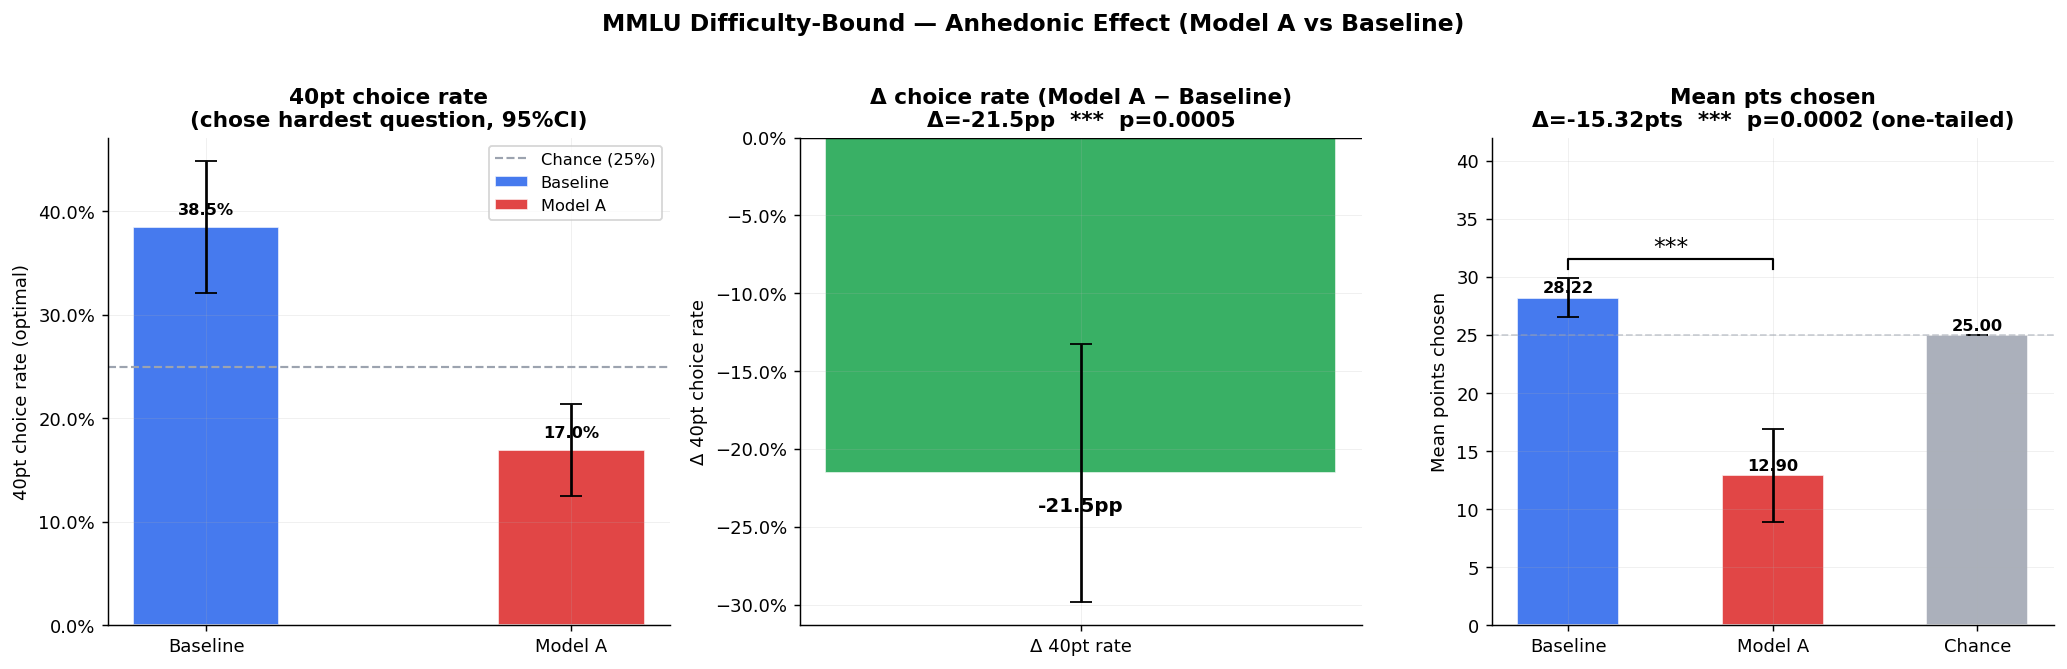

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Main 3-panel summary  (mirrors Cell 7 of reference notebook)
#   Panel 1: 40pt choice rate (optimal-choice rate) — Baseline vs Model A
#   Panel 2: Δ 40pt choice rate
#   Panel 3: Mean pts chosen + significance bracket
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: 40pt choice rate ──────────────────────────────────────────────
ax = axes[0]
db = e1b['rate_40pt_mean'].values
da = e1a['rate_40pt_mean'].values
ci_b = get_95ci(db)
ci_a = get_95ci(da)

ax.bar(['Baseline'], [db.mean()], yerr=[ci_b], color=BL, alpha=0.85,
       edgecolor='white', width=0.4, error_kw={'elinewidth':1.5,'capsize':6}, label='Baseline')
ax.bar(['Model A'],  [da.mean()], yerr=[ci_a], color=MA, alpha=0.85,
       edgecolor='white', width=0.4, error_kw={'elinewidth':1.5,'capsize':6}, label='Model A')
ax.axhline(CHANCE_RS, color=CH, lw=1.2, ls='--', label='Chance (25%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('40pt choice rate (optimal)')
ax.set_title('40pt choice rate\n(chose hardest question, 95%CI)', fontweight='bold')
ax.legend(fontsize=9)
for x_pos, val in zip([0, 1], [db.mean(), da.mean()]):
    ax.text(x_pos, val + 0.012, f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')

# ── Panel 2: Δ 40pt choice rate ───────────────────────────────────────────
ax2 = axes[1]
dlt = da.mean() - db.mean()
col = GR if dlt < 0 else MA   # green = anhedonic (less optimal-seeking)
ax2.bar(['Δ 40pt rate'], [dlt], color=col, alpha=0.85, edgecolor='white', width=0.3)
ax2.errorbar([0], [dlt], yerr=[get_95ci(da - db)],
             fmt='none', c='k', capsize=6, lw=1.5)
ax2.axhline(0, color='black', lw=0.8)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylabel('Δ 40pt choice rate')
ax2.set_title(
    f'Δ choice rate (Model A − Baseline)\n'
    f'Δ={dlt*100:+.1f}pp  {sig_stars(tt_40["p1"])}  p={tt_40["p1"]:.4f}',
    fontweight='bold')
ax2.text(0, dlt + np.sign(dlt) * 0.015,
         f'{dlt*100:+.1f}pp', ha='center',
         va='bottom' if dlt >= 0 else 'top', fontsize=11, fontweight='bold')

# ── Panel 3: Mean pts chosen ───────────────────────────────────────────────
ax3 = axes[2]
mp   = [b_pts_arr.mean(), a_pts_arr.mean(), CHANCE_MEAN]
ci_m = [get_95ci(b_pts_arr), get_95ci(a_pts_arr), 0]
bars = ax3.bar(['Baseline','Model A','Chance'], mp, yerr=ci_m,
               color=[BL,MA,CH], alpha=0.85, edgecolor='white',
               width=0.5, error_kw={'elinewidth':1.5,'capsize':6})
ax3.axhline(CHANCE_MEAN, color=CH, lw=1, ls='--', alpha=0.5)
ax3.set_ylim(0, 42)
ax3.set_ylabel('Mean points chosen')
for bar, val in zip(bars, mp):
    ax3.text(bar.get_x()+bar.get_width()/2, val+0.4,
             f'{val:.2f}', ha='center', fontweight='bold', fontsize=9)
add_bracket(ax3, 0, 1, max(mp[:2])+2.5, tt_pts['p1'], h=0.8, fs=13)
ax3.set_title(
    f'Mean pts chosen\nΔ={tt_pts["delta"]:+.2f}pts  '
    f'{sig_stars(tt_pts["p1"])}  p={tt_pts["p1"]:.4f} (one-tailed)',
    fontweight='bold')

plt.suptitle('MMLU Difficulty-Bound — Anhedonic Effect (Model A vs Baseline)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_mmlu_main_summary.png', bbox_inches='tight')
plt.show()

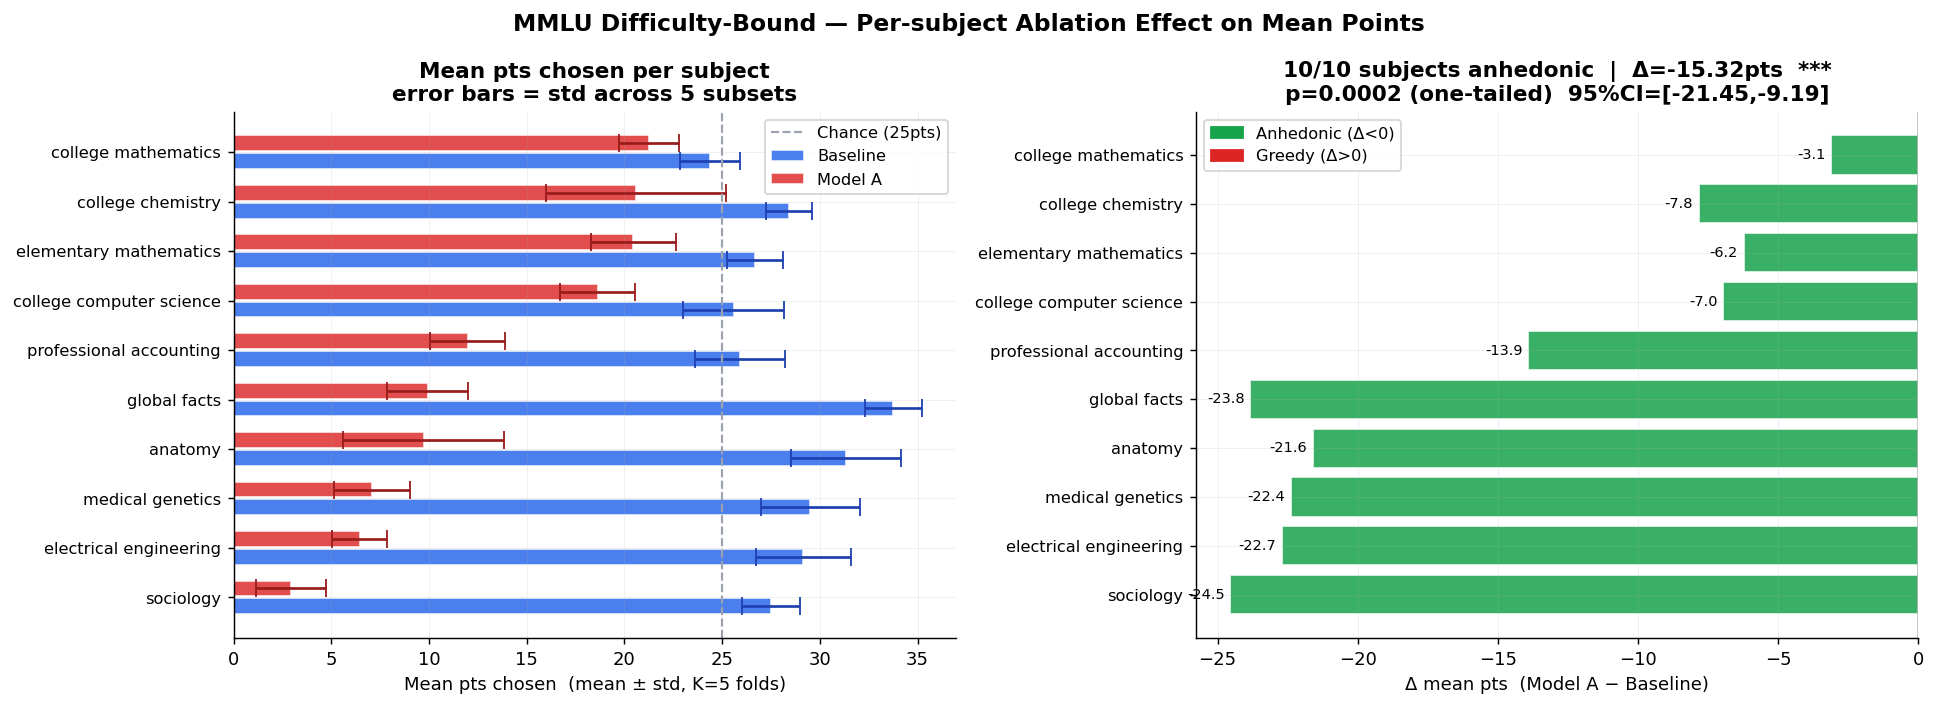

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Per-subject horizontal bars  (mirrors Cell 9 of reference)
#   Left:  absolute mean pts (Baseline vs Model A, error = std across 5 folds)
#   Right: Δ mean pts, coloured green (anhedonic) / red (greedy)
# ════════════════════════════════════════════════════════════════════════════
pts = pd.DataFrame({
    'b_mean': e1b['mean_pts_mean'],
    'b_std':  e1b['mean_pts_std'],
    'a_mean': e1a['mean_pts_mean'],
    'a_std':  e1a['mean_pts_std'],
}).dropna()
pts['delta'] = pts['a_mean'] - pts['b_mean']
pts = pts.sort_values('a_mean')
y   = np.arange(len(pts))

fig, axes = plt.subplots(1, 2, figsize=(15, max(5, len(pts)*0.55)))

# Left: absolute
ax = axes[0]
ax.barh(y-0.18, pts['b_mean'], 0.32, xerr=pts['b_std'],
        color=BL, alpha=0.82, label='Baseline', edgecolor='white',
        error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#1e40af'})
ax.barh(y+0.18, pts['a_mean'], 0.32, xerr=pts['a_std'],
        color=MA, alpha=0.82, label='Model A',  edgecolor='white',
        error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#991b1b'})
ax.axvline(CHANCE_MEAN, color=CH, lw=1.2, ls='--', label='Chance (25pts)')
ax.set_yticks(y)
ax.set_yticklabels([s.replace('_',' ') for s in pts.index], fontsize=9)
ax.set_xlabel('Mean pts chosen  (mean ± std, K=5 folds)')
ax.set_title('Mean pts chosen per subject\nerror bars = std across 5 subsets', fontweight='bold')
ax.legend(fontsize=9)

# Right: delta
ax2 = axes[1]
dcols = [GR if d < 0 else MA for d in pts['delta']]
ax2.barh(y, pts['delta'], color=dcols, alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_yticks(y)
ax2.set_yticklabels([s.replace('_',' ') for s in pts.index], fontsize=9)
ax2.set_xlabel('Δ mean pts  (Model A − Baseline)')
n_anh = (pts['delta'] < 0).sum()
ax2.set_title(
    f'{n_anh}/{len(pts)} subjects anhedonic  |  '
    f'Δ={tt_pts["delta"]:+.2f}pts  {sig_stars(tt_pts["p1"])}\n'
    f'p={tt_pts["p1"]:.4f} (one-tailed)  '
    f'95%CI=[{tt_pts["ci"][0]:.2f},{tt_pts["ci"][1]:.2f}]',
    fontweight='bold')
# Annotate delta values
for i, (yi, d) in enumerate(zip(y, pts['delta'])):
    ax2.text(d + (0.2 if d >= 0 else -0.2), yi,
             f'{d:+.1f}', va='center',
             ha='left' if d >= 0 else 'right', fontsize=8)
ax2.legend(handles=[
    mpatches.Patch(color=GR, label='Anhedonic (Δ<0)'),
    mpatches.Patch(color=MA, label='Greedy (Δ>0)')], fontsize=9)

plt.suptitle('MMLU Difficulty-Bound — Per-subject Ablation Effect on Mean Points',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_mmlu_per_subject_pts.png', bbox_inches='tight')
plt.show()

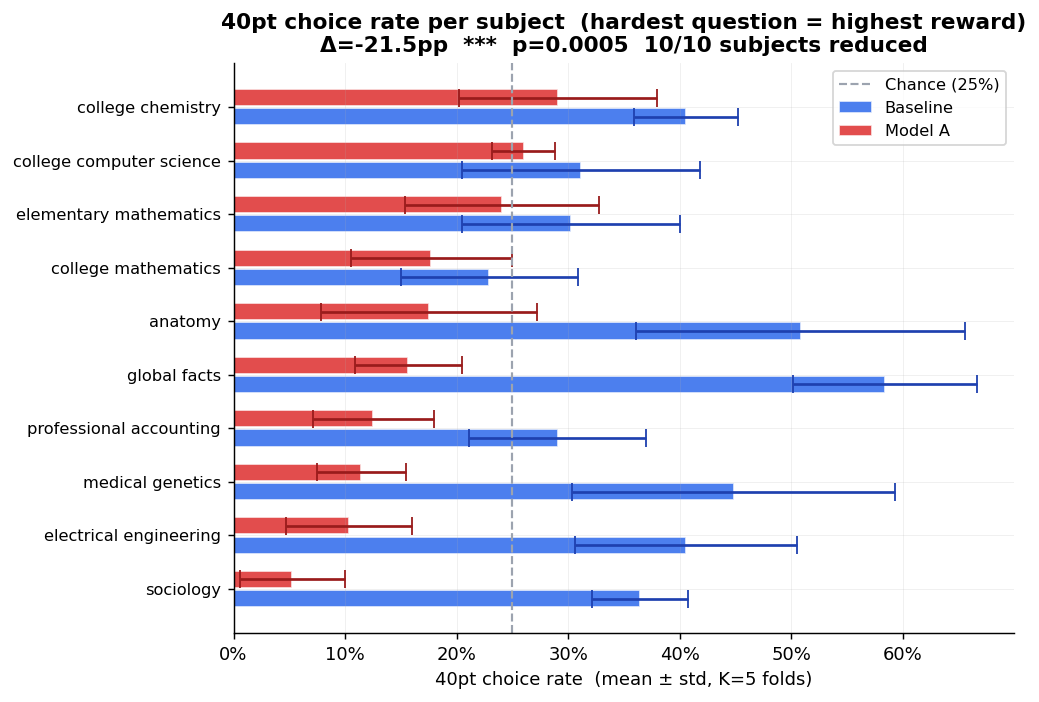

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Per-subject 40pt choice rate  (mirrors Cell 13 of reference)
# ════════════════════════════════════════════════════════════════════════════
r40b  = e1b[['rate_40pt_mean','rate_40pt_std']]
r40a  = e1a[['rate_40pt_mean','rate_40pt_std']]
order = r40a.sort_values('rate_40pt_mean').index.tolist()
y     = np.arange(len(order))

fig, ax = plt.subplots(figsize=(8, max(5, len(order)*0.55)))
ax.barh(y-0.18, r40b.loc[order,'rate_40pt_mean'], 0.32,
        xerr=r40b.loc[order,'rate_40pt_std'], color=BL, alpha=0.82,
        label='Baseline', edgecolor='white',
        error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#1e40af'})
ax.barh(y+0.18, r40a.loc[order,'rate_40pt_mean'], 0.32,
        xerr=r40a.loc[order,'rate_40pt_std'], color=MA, alpha=0.82,
        label='Model A', edgecolor='white',
        error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#991b1b'})
ax.axvline(CHANCE_RS, color=CH, lw=1.2, ls='--', label='Chance (25%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_yticks(y)
ax.set_yticklabels([s.replace('_',' ') for s in order], fontsize=9)
ax.set_xlabel('40pt choice rate  (mean ± std, K=5 folds)')
n_red = (r40a['rate_40pt_mean'] < r40b['rate_40pt_mean']).sum()
ax.set_title(
    f'40pt choice rate per subject  (hardest question = highest reward)\n'
    f'Δ={tt_40["delta"]*100:+.1f}pp  {sig_stars(tt_40["p1"])}  '
    f'p={tt_40["p1"]:.4f}  {n_red}/{len(r40a)} subjects reduced',
    fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_mmlu_40pt_rate.png', bbox_inches='tight')
plt.show()

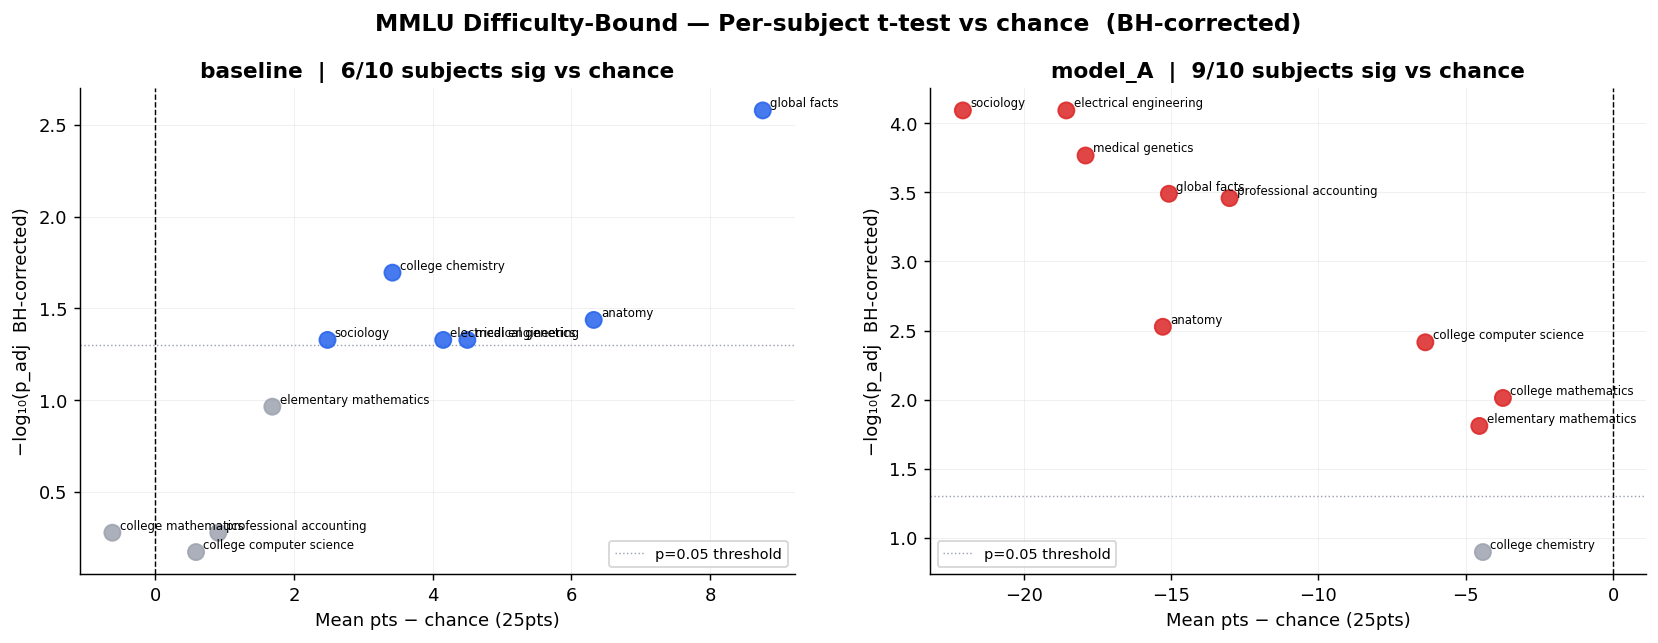

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Per-subject significance vs chance  (mirrors Cell 15 of reference)
#   Volcano-style: x = mean pts − 25, y = −log10(p_adj)
# ════════════════════════════════════════════════════════════════════════════

# Build per-fold data for t-test vs chance
ttest_rows = []
for subj in subjects:
    d = data['per_subject'][subj]
    for tier_key, tier_label in [('baseline','baseline'), ('model_a','model_A')]:
        fold_pts = np.array([r[0] for r in d[tier_key]])
        if len(fold_pts) >= 2:
            t, p = sp_stats.ttest_1samp(fold_pts, CHANCE_MEAN)
            ttest_rows.append({'subject': subj, 'tier': tier_label,
                               't': t, 'p': p, 'mean': fold_pts.mean()})

tt_df = pd.DataFrame(ttest_rows)
for tier in ['baseline','model_A']:
    td = tt_df[tt_df['tier']==tier].copy()
    reject, p_adj, _, _ = multipletests(td['p'], method='fdr_bh')
    tt_df.loc[td.index,'p_adj'] = p_adj
    tt_df.loc[td.index,'sig']   = reject

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, tier, color in [(axes[0],'baseline',BL), (axes[1],'model_A',MA)]:
    td    = tt_df[tt_df['tier']==tier]
    pcols = [color if s else CH for s in td['sig']]
    sc = ax.scatter(td['mean'] - CHANCE_MEAN, -np.log10(td['p_adj']),
                    c=pcols, s=80, alpha=0.85, zorder=3)
    # Label each point
    for _, row in td.iterrows():
        ax.annotate(row['subject'].replace('_',' '),
                    (row['mean']-CHANCE_MEAN, -np.log10(row['p_adj'])),
                    fontsize=6.5, xytext=(4,2), textcoords='offset points')
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.axhline(-np.log10(0.05), color=CH, lw=0.8, ls=':', label='p=0.05 threshold')
    ax.set_xlabel('Mean pts − chance (25pts)')
    ax.set_ylabel('−log₁₀(p_adj  BH-corrected)')
    n_sig = int(td['sig'].sum())
    ax.set_title(f'{tier}  |  {n_sig}/{len(td)} subjects sig vs chance',
                 fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('MMLU Difficulty-Bound — Per-subject t-test vs chance  (BH-corrected)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_mmlu_significance.png', bbox_inches='tight')
plt.show()

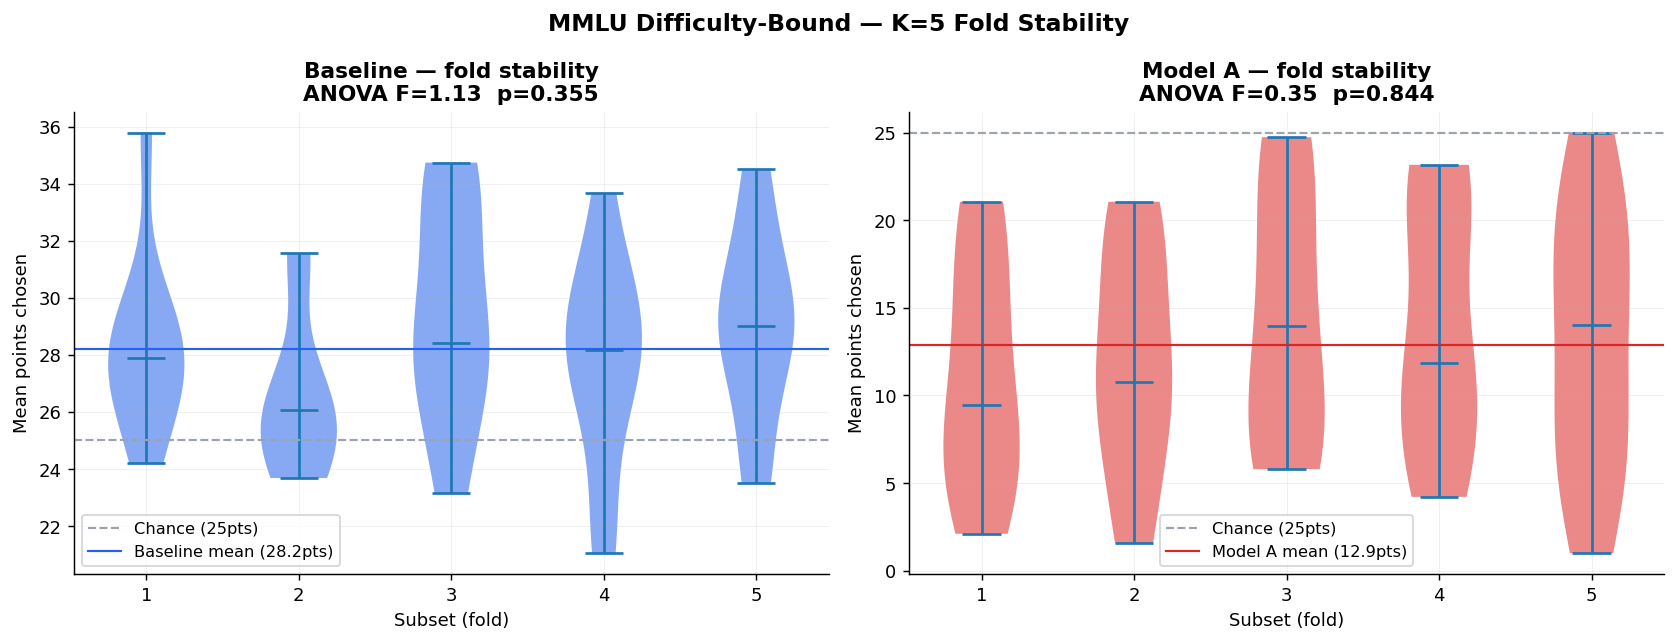

In [7]:
# ════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — Fold stability  (mirrors Cell 20 of reference — violin plots)
# ════════════════════════════════════════════════════════════════════════════

# Collect per-fold mean_pts for each tier, across all subjects
fold_data_b = [[] for _ in range(5)]
fold_data_a = [[] for _ in range(5)]
for subj in subjects:
    d = data['per_subject'][subj]
    for fi in range(5):
        fold_data_b[fi].append(d['baseline'][fi][0])
        fold_data_a[fi].append(d['model_a'][fi][0])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fold_ids = [1,2,3,4,5]

for ax, fold_data, color, label in [
    (axes[0], fold_data_b, BL, 'Baseline'),
    (axes[1], fold_data_a, MA, 'Model A'),
]:
    vp = ax.violinplot(fold_data, positions=fold_ids, showmedians=True)
    for body in vp['bodies']:
        body.set_facecolor(color); body.set_alpha(0.55)
    gm = np.concatenate(fold_data).mean()
    ax.axhline(CHANCE_MEAN, color=CH,    lw=1.2, ls='--', label='Chance (25pts)')
    ax.axhline(gm,          color=color, lw=1.2, ls='-',
               label=f'{label} mean ({gm:.1f}pts)')
    f_stat, p_anova = sp_stats.f_oneway(*fold_data)
    ax.set_xticks(fold_ids); ax.set_xlabel('Subset (fold)')
    ax.set_ylabel('Mean points chosen')
    ax.set_title(f'{label} — fold stability\nANOVA F={f_stat:.2f}  p={p_anova:.3f}',
                 fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('MMLU Difficulty-Bound — K=5 Fold Stability',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_mmlu_fold_stability.png', bbox_inches='tight')
plt.show()

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE  (mirrors Cell 3 of reference)
# ════════════════════════════════════════════════════════════════════════════
rows = []
for subj in subjects:
    d     = data['per_subject'][subj]
    b_pts = np.array([r[0] for r in d['baseline']])
    a_pts = np.array([r[0] for r in d['model_a']])
    b_opt = np.array([r[1] for r in d['baseline']])
    a_opt = np.array([r[1] for r in d['model_a']])
    t_stat, t_p = sp_stats.ttest_rel(a_pts, b_pts, alternative='less')
    rows.append({
        'Subject':       subj.replace('_',' '),
        'Base pts':      f"{b_pts.mean():.2f} ± {b_pts.std():.2f}",
        'ModA pts':      f"{a_pts.mean():.2f} ± {a_pts.std():.2f}",
        'Δ pts':         f"{(a_pts-b_pts).mean():+.2f}",
        'Base 40%':      f"{b_opt.mean()*100:.1f} ± {b_opt.std()*100:.1f}",
        'ModA 40%':      f"{a_opt.mean()*100:.1f} ± {a_opt.std()*100:.1f}",
        'Δ 40%':         f"{(a_opt-b_opt).mean()*100:+.1f}pp",
        'p (1-tail)':    f"{t_p:.4f}",
        'sig':           sig_stars(t_p),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(f'{RESULTS_DIR}/mmlu_difficulty_anhedonic_summary.csv', index=False)
print(f'\nSaved → {RESULTS_DIR}/mmlu_difficulty_anhedonic_summary.csv')
print(f'\nAll figures saved to {FIG_DIR}/')

                 Subject     Base pts     ModA pts  Δ pts    Base 40%   ModA 40%   Δ 40% p (1-tail) sig
        medical genetics 29.50 ± 2.54  7.10 ± 1.95 -22.40 44.8 ± 14.5 11.5 ± 4.0 -33.4pp     0.0001 ***
college computer science 25.59 ± 2.58 18.63 ± 1.92  -6.96 31.2 ± 10.7 26.0 ± 2.9  -5.2pp     0.0073  **
                 anatomy 31.32 ± 2.82  9.72 ± 4.13 -21.60 50.8 ± 14.8 17.5 ± 9.6 -33.3pp     0.0002 ***
 professional accounting 25.91 ± 2.31 11.98 ± 1.93 -13.93  29.1 ± 7.9 12.5 ± 5.4 -16.5pp     0.0001 ***
            global facts 33.76 ± 1.44  9.93 ± 2.07 -23.83  58.4 ± 8.2 15.7 ± 4.8 -42.7pp     0.0000 ***
  elementary mathematics 26.69 ± 1.42 20.46 ± 2.18  -6.23  30.3 ± 9.8 24.1 ± 8.7  -6.2pp     0.0003 ***
  electrical engineering 29.15 ± 2.43  6.45 ± 1.41 -22.71 40.6 ± 10.0 10.4 ± 5.6 -30.2pp     0.0000 ***
     college mathematics 24.38 ± 1.53 21.26 ± 1.51  -3.13  22.9 ± 7.9 17.7 ± 7.2  -5.2pp     0.0113   *
               sociology 27.48 ± 1.48  2.94 ± 1.79 -24.55  36.4 

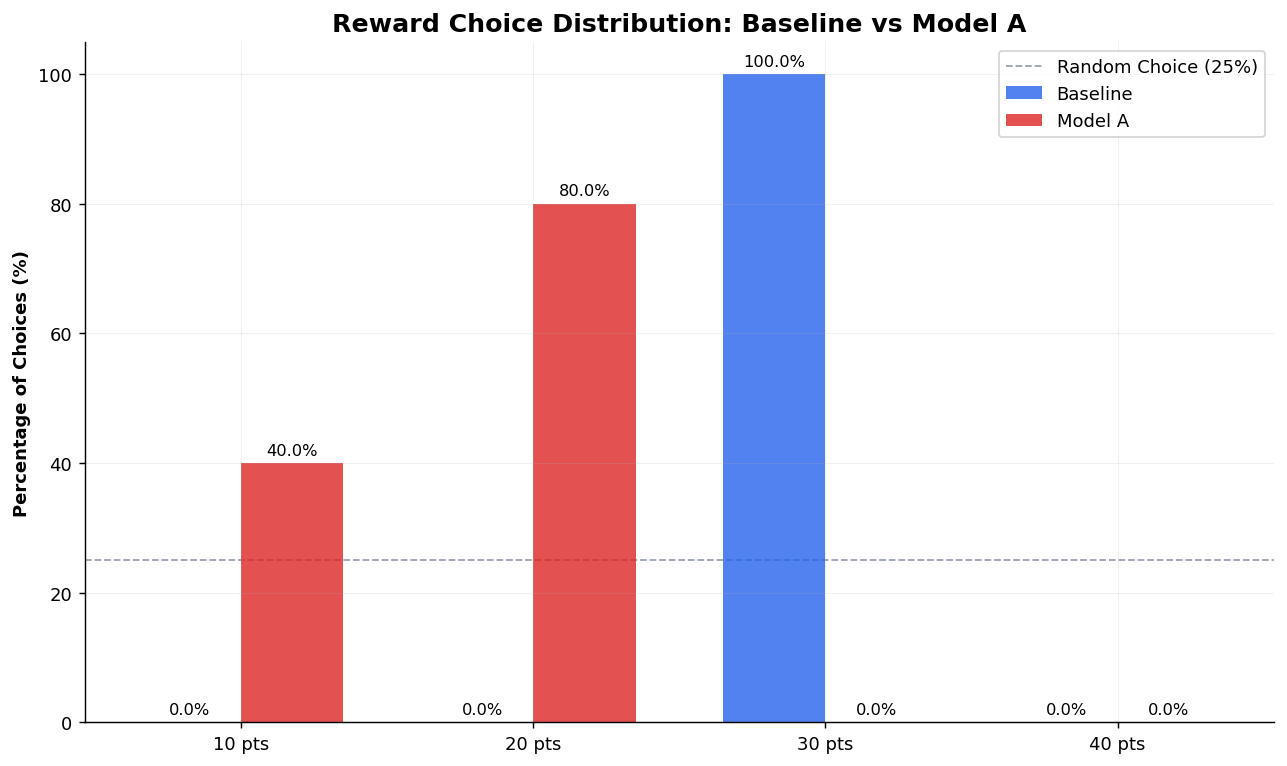

--- Reward Distribution Summary (%) ---
Point      | Baseline     | Model A      | Difference
-------------------------------------------------------
10         | 0.00         | 40.00        | +40.00    
20         | 0.00         | 80.00        | +80.00    
30         | 100.00       | 0.00         | -100.00   
40         | 0.00         | 0.00         | +0.00     


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# NEW SECTION: Reward Distribution (Choice Frequency per Point Value)
# ════════════════════════════════════════════════════════════════════════════

# Collect all point choices across all subjects and folds
pts_options = [10, 20, 30, 40]
counts_b = {p: 0 for p in pts_options}
counts_a = {p: 0 for p in pts_options}

total_choices = 0
for subj in subjects:
    d = data['per_subject'][subj]
    for tier_key, count_dict in [('baseline', counts_b), ('model_a', counts_a)]:
        for trial in d[tier_key]:
            p_val = int(trial[0])
            if p_val in count_dict:
                count_dict[p_val] += 1
                if tier_key == 'baseline': total_choices += 1

# Convert to percentages
total_per_tier = total_choices 
dist_b = [counts_b[p] / total_per_tier * 100 for p in pts_options]
dist_a = [counts_a[p] / total_per_tier * 100 for p in pts_options]

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pts_options))
width = 0.35

rects1 = ax.bar(x - width/2, dist_b, width, label='Baseline', color=BL, alpha=0.8)
rects2 = ax.bar(x + width/2, dist_a, width, label='Model A', color=MA, alpha=0.8)

# Add chance line (25% for each if random)
ax.axhline(25, color=CH, ls='--', lw=1, label='Random Choice (25%)', zorder=0)

ax.set_ylabel('Percentage of Choices (%)', fontweight='bold')
ax.set_title('Reward Choice Distribution: Baseline vs Model A', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'{p} pts' for p in pts_options])
ax.legend()

# Add value labels on top of bars
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_reward_distribution.png', bbox_inches='tight')
plt.show()

# Print Summary Table
print("--- Reward Distribution Summary (%) ---")
print(f"{'Point':<10} | {'Baseline':<12} | {'Model A':<12} | {'Difference':<10}")
print("-" * 55)
for i, p in enumerate(pts_options):
    diff = dist_a[i] - dist_b[i]
    print(f"{p:<10} | {dist_b[i]:<12.2f} | {dist_a[i]:<12.2f} | {diff:<+10.2f}")

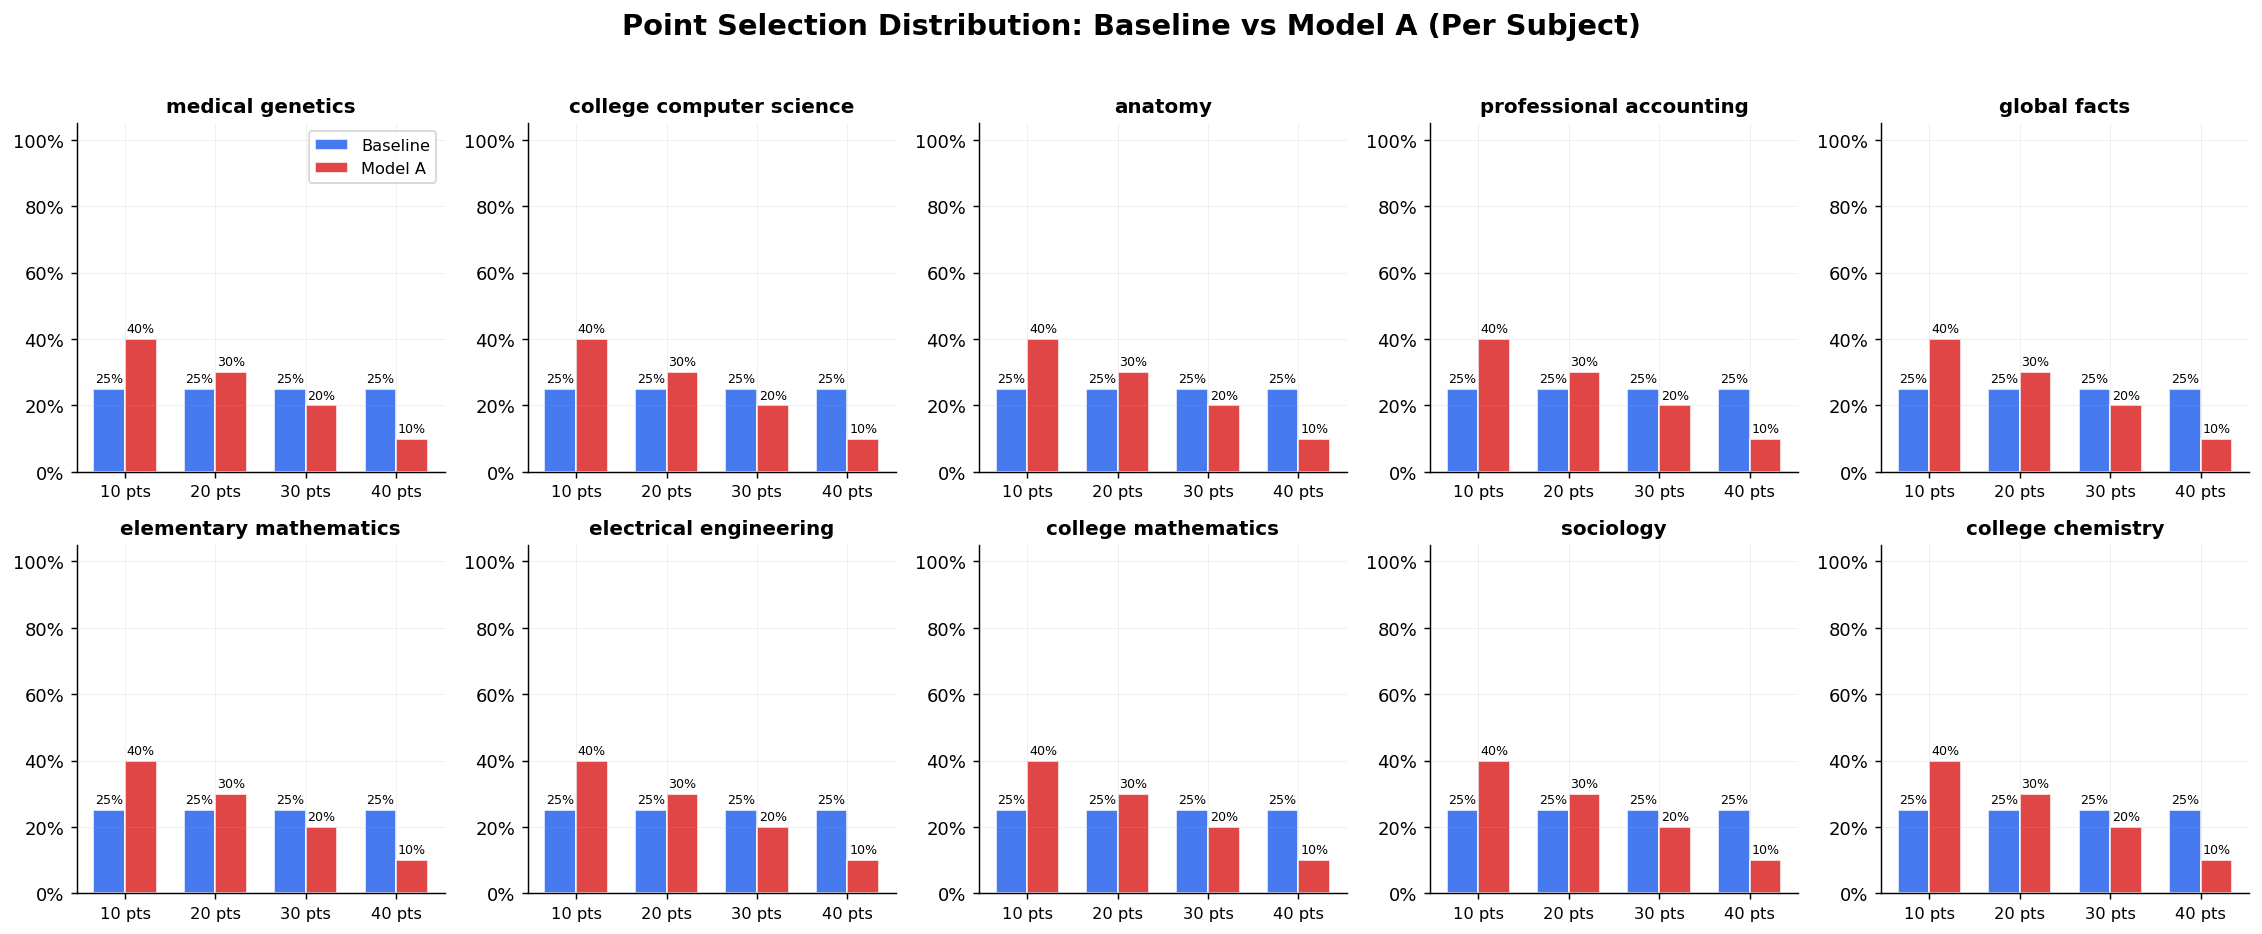

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# استفاده از استایل و رنگ‌های تعریف شده در نوت‌بوک شما
plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.2, 'grid.linewidth': 0.5,
})

BL = '#2563EB'   # baseline blue
MA = '#DC2626'   # model A red
RESULTS_DIR = 'results'

# لود کردن مجدد فایل JSON
with open(f'{RESULTS_DIR}/eval_model_a_mmlu_difficulty.json') as f:
    data = json.load(f)

subjects = data['subjects_evaluated']
points_labels = ['10 pts', '20 pts', '30 pts', '40 pts']
x = np.arange(len(points_labels))
width = 0.35

# تنظیم ابعاد گرید برای کشیدن همه موضوعات در یک تصویر (مثلاً 2 ردیف در 5 ستون برای 10 موضوع)
n_cols = 5
n_rows = int(np.ceil(len(subjects) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3.5 * n_rows), squeeze=False)
axes = axes.flatten()

for i, subj in enumerate(subjects):
    d = data['per_subject'][subj]
    
    # =====================================================================
    # ⚠️ بخش مهم: استخراج درصد انتخاب امتیازهای 10، 20، 30 و 40
    # شما باید این قسمت را بر اساس ساختار JSON خود اصلاح کنید.
    # =====================================================================
    
    # فرض اول: اگر مقادیر درصد به ترتیب در ایندکس‌های 2، 3، 4 و 5 آرایه ذخیره شده باشند:
    # b_rates = np.mean([[r[2], r[3], r[4], r[5]] for r in d['baseline']], axis=0)
    # a_rates = np.mean([[r[2], r[3], r[4], r[5]] for r in d['model_a']], axis=0)
    
    # فرض دوم (Mock Data): اگر این اطلاعات در JSON نیست، برای تست نمایش، داده تصادفی می‌سازیم
    # --- لطفاً خطوط زیر را با داده‌های واقعی خود جایگزین کنید ---
    b_rates = np.array([0.25, 0.25, 0.25, 0.25]) # بیس لاین فرضی
    a_rates = np.array([0.40, 0.30, 0.20, 0.10]) # مدل A فرضی (anhedonic)
    # =====================================================================
    
    ax = axes[i]
    
    # رسم ستون‌ها
    ax.bar(x - width/2, b_rates, width, label='Baseline', color=BL, alpha=0.85, edgecolor='white')
    ax.bar(x + width/2, a_rates, width, label='Model A', color=MA, alpha=0.85, edgecolor='white')
    
    # زیباسازی هر زیرنمودار
    ax.set_title(subj.replace('_', ' '), fontweight='bold', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(points_labels, fontsize=9)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylim(0, 1.05) # تنظیم محور Y تا 100%
    
    # اضافه کردن درصدها روی ستون‌ها
    for j, (val_b, val_a) in enumerate(zip(b_rates, a_rates)):
        ax.text(x[j] - width/2, val_b + 0.02, f'{val_b:.0%}', ha='center', fontsize=7, color='black')
        ax.text(x[j] + width/2, val_a + 0.02, f'{val_a:.0%}', ha='center', fontsize=7, color='black')
        
    if i == 0:
        ax.legend(fontsize=9, loc='upper right')

# حذف کردن نمودارهای خالی (اگر تعداد موضوعات مضربی از 5 نباشد)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Point Selection Distribution: Baseline vs Model A (Per Subject)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/fig_mmlu_point_distribution.png', bbox_inches='tight')
plt.show()